Ayush Yonghang | 2358879
Workshop 5

In [ ]:
!gdown 1pE2puCp0KKkLPgDgvlQCEvAVUXauFPca


Downloading...
From: https://drive.google.com/uc?id=1pE2puCp0KKkLPgDgvlQCEvAVUXauFPca
To: /content/Copy of FruitinAmazon.zip
100% 1.24M/1.24M [00:00<00:00, 14.6MB/s]


In [ ]:
!unzip FruitinAmazon.zip

Archive:  FruitinAmazon.zip
replace FruitinAmazon/test/cupuacu/download (5).jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: FruitinAmazon/test/cupuacu/download (5).jpeg  
replace FruitinAmazon/test/acai/images (2).jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: FruitinAmazon/test/acai/images (2).jpeg  
replace FruitinAmazon/test/cupuacu/download (3).jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: FruitinAmazon/test/cupuacu/download (3).jpeg  
replace FruitinAmazon/test/acai/images (16).jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: FruitinAmazon/test/acai/images (16).jpeg  
replace FruitinAmazon/test/pupunha/download (2).jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: FruitinAmazon/test/pupunha/download (2).jpeg  
replace FruitinAmazon/train/pupunha/images (1).jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: FruitinAmazon/train/pupunha/images (1).jpeg  
replace FruitinAmazon/test/cupuacu/download (2).jpeg? [y]es, [n]o, [

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import random
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report


# Task 1: Data Understanding and Visualization

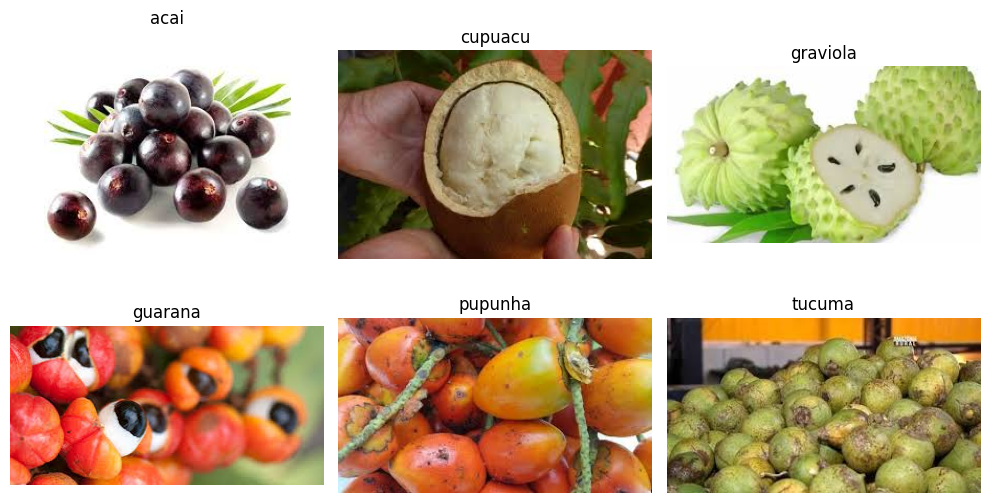

['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [ ]:
train_dir = "/content/FruitinAmazon/train"
test_dir = "/content/FruitinAmazon/test"

class_names = sorted(os.listdir(train_dir))
num_classes = len(class_names)

plt.figure(figsize=(10, 8))
for i, class_name in enumerate(class_names):
  class_dir = os.path.join(train_dir, class_name)
  images = os.listdir(class_dir)
  img_name = random.choice(images)
  img_path = os.path.join(class_dir, img_name)
  img = Image.open(img_path)

  plt.subplot(3,3,i+1)
  plt.imshow(img)
  plt.title(class_name)
  plt.axis('off')

plt.tight_layout()
plt.show()
print(class_names)



In [ ]:
#checking corrupted images
corrupted = []
for class_name in class_names:
  class_dir = os.path.join(train_dir,class_name)
  for img_name in os.listdir(class_dir):
    img_path = os.path.join(class_dir, img_name)
    try:
      img = Image.open(img_path)
      img.verify()
    except:
      corrupted.append(img_path)
      os.remove(img_path)
      print(f"Removed corrupted image:{img_path}")

  if not corrupted:
    print("No corrupted images found.")

No corrupted images found.
No corrupted images found.
No corrupted images found.
No corrupted images found.
No corrupted images found.
No corrupted images found.


# Loading and Processing Image Data in Keras

In [ ]:
img_height, img_width = 128, 128
batch_size = 32
validation_split = 0.2

rescale = tf.keras.layers.Rescaling(1./255)

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels = 'inferred',
    label_mode = 'int',
    image_size = (img_height, img_width),
    batch_size = batch_size,
    shuffle = True,
    validation_split = validation_split,
    subset = 'training',
    seed = 123
)

train_ds = train_ds.map(lambda x, y: (rescale(x),y))

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels = 'inferred',
    label_mode = 'int',
    image_size = (img_height, img_width),
    batch_size = batch_size,
    shuffle = False,
    validation_split = validation_split,
    subset = 'validation',
    seed = 123
)

val_ds = val_ds.map(lambda x, y: (rescale(x),y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


# Task 3 - Implement CNN with Convolution Architecture and FCN Architecture

In [ ]:
model = tf.keras.Sequential([
    #convolution Architecture
    tf.keras.layers.Conv2D(32,(3,3), activation='relu', padding = 'same',
    input_shape = (img_height, img_width,3), strides=1),
    tf.keras.layers.MaxPooling2D((2,2), strides = 2),
    tf.keras.layers.Conv2D(32,(3,3), strides=1,padding="same", activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2), strides = 2),

    #FCN Architecture
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(num_classes, activation="softmax")
])

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 64, 64, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │       2,097,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

# Task 4 - Compile the Model

In [ ]:
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

# Task 5 - Train the Model

In [ ]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint('best_model.h5', save_best_only = True, monitor = 'val_loss'),
    tf.keras.callbacks.EarlyStopping(monitor = 'val_loss', patience = 10, restore_best_weights = True)

]
history = model.fit(
    train_ds,
    epochs = 250,
    batch_size = 16,
    validation_data = val_ds,
    callbacks = callbacks
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - accuracy: 0.2350 - loss: 1.9151

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 580ms/step - accuracy: 0.2352 - loss: 1.9366 - val_accuracy: 0.8333 - val_loss: 1.2909
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 447ms/step - accuracy: 0.1458 - loss: 1.8537 - val_accuracy: 0.2222 - val_loss: 1.6618
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 413ms/step - accuracy: 0.4002 - loss: 1.6409 - val_accuracy: 0.1111 - val_loss: 1.7409
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 445ms/step - accuracy: 0.3989 - loss: 1.4692 - val_accuracy: 0.0556 - val_loss: 1.8091
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 574ms/step - accuracy: 0.6476 - loss: 1.1743 - val_accuracy: 0.3333 - val_loss: 1.5068
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 451ms/step - accuracy: 0.7461 - loss: 0.9520 - val_accuracy: 0.3333 - val_loss: 1.7016
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.6991 - loss: 0.8287

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 493ms/step - accuracy: 0.7049 - loss: 0.8297 - val_accuracy: 0.8333 - val_loss: 0.8725
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.9016 - loss: 0.5583

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 490ms/step - accuracy: 0.8915 - loss: 0.5707 - val_accuracy: 0.8889 - val_loss: 0.6973
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 422ms/step - accuracy: 0.9605 - loss: 0.3814 - val_accuracy: 0.6111 - val_loss: 0.8235
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.9300 - loss: 0.2998

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 468ms/step - accuracy: 0.9301 - loss: 0.2994 - val_accuracy: 0.8333 - val_loss: 0.4400
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 0.9196 - loss: 0.2854

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 473ms/step - accuracy: 0.9223 - loss: 0.2813 - val_accuracy: 0.8889 - val_loss: 0.3375
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 629ms/step - accuracy: 0.9813 - loss: 0.1598 - val_accuracy: 0.7778 - val_loss: 1.0668
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 429ms/step - accuracy: 0.9783 - loss: 0.2027 - val_accuracy: 0.8333 - val_loss: 0.3533
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 1.0000 - loss: 0.0450

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 484ms/step - accuracy: 1.0000 - loss: 0.0456 - val_accuracy: 0.9444 - val_loss: 0.1759
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 431ms/step - accuracy: 1.0000 - loss: 0.0792 - val_accuracy: 0.9444 - val_loss: 0.2424
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 439ms/step - accuracy: 1.0000 - loss: 0.0351 - val_accuracy: 0.8889 - val_loss: 0.4010
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 417ms/step - accuracy: 1.0000 - loss: 0.0264 - val_accuracy: 0.8333 - val_loss: 0.4216
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 783ms/step - accuracy: 1.0000 - loss: 0.0151 - val_accuracy: 0.8333 - val_loss: 0.3860
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 811ms/step - accuracy: 1.0000 - loss: 0.0097 - val_accuracy: 0.8333 - val_loss: 0.3488
Epoch 20/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 460ms/step - accuracy: 1.0000 - loss: 0.0086 - val_accuracy: 0.8333 - val_loss: 0.3321
Epoch 21/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 418ms/step - accuracy: 1.0000 - loss: 0.0074 - val_accuracy: 0.8333 - val_lo

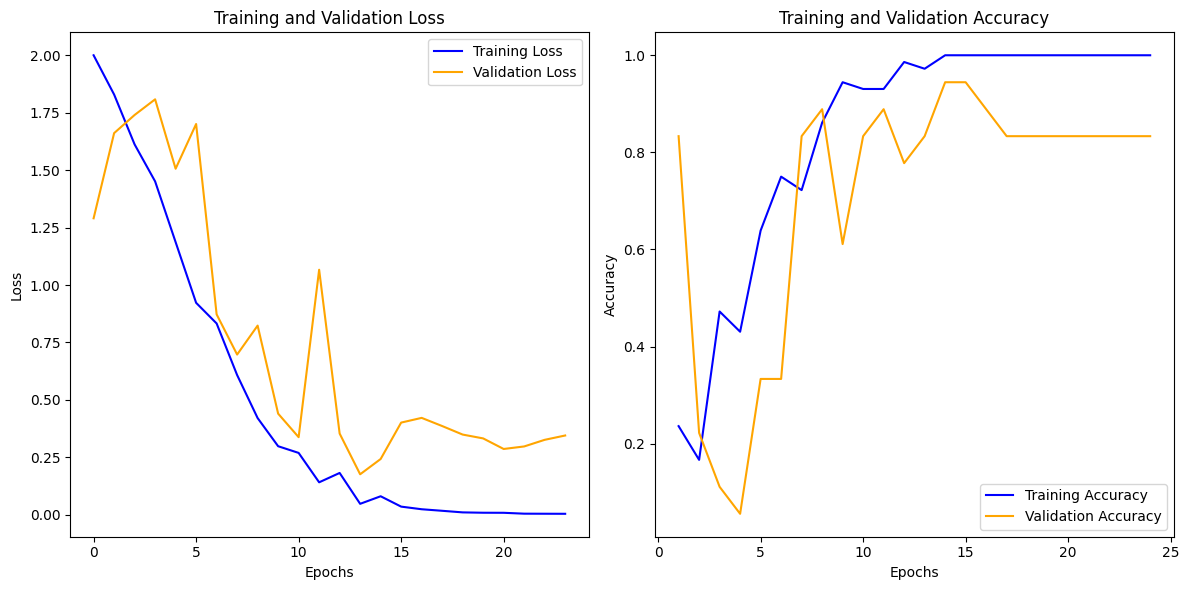

In [ ]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']

train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.plot(train_loss, label='Training Loss', color ='blue')
plt.plot(val_loss, label= 'Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(range(1, len(train_acc)+1), train_acc, label="Training Accuracy", color='blue')
plt.plot(range(1,len(val_acc)+1), val_acc, label ="Validation Accuracy", color="orange")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Task 6 - Evaluate Model

In [ ]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(img_height,img_width),
    batch_size=batch_size,
)

test_ds = test_ds.map(lambda x,y:(rescale(x),y))

test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_acc}")

Found 30 files belonging to 6 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.7333 - loss: 0.7115
Test Loss: 0.7115054726600647
Test Accuracy: 0.7333333492279053


# Task 7 - Save and Load Model

In [ ]:
model.save('classifier_model.h5')
load_model = tf.keras.models.load_model('classifier_model.h5')
load_model.evaluate(test_ds)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.7333 - loss: 0.7115


[0.7115053534507751, 0.7333333492279053]

# Task 8 - Predictions and Classification Report

In [ ]:
prediction = load_model.predict(test_ds)
predicted_labels = np.argmax(prediction, axis =1)

true_labels = np.concatenate([y for x,y in test_ds], axis=0)

print(classification_report(
    true_labels,
    predicted_labels,
    target_names = class_names
))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         5
     cupuacu       0.00      0.00      0.00         5
    graviola       0.25      0.20      0.22         5
     guarana       0.12      0.20      0.15         5
     pupunha       0.33      0.20      0.25         5
      tucuma       0.22      0.40      0.29         5

    accuracy                           0.17        30
   macro avg       0.16      0.17      0.15        30
weighted avg       0.16      0.17      0.15        30

